In [1]:
from pathlib import Path
from src.db import get_connection
import sqlite3

import numpy as np
import pandas as pd

import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")


DATABASE_PATH = Path.home() / "HDD/Datasets/annas_archive_spotify_2025_07/spotify_clean_playlists.sqlite3"

cuda available
gpu ready


In [2]:
conn  = get_connection(DATABASE_PATH)
print("Connected to database")

Connected to database


In [3]:
def fetch_topn_playlist_tracks(conn, n):
    """Fetch all valid (playlist_rowid, track_rowid) pairs for the top N playlists
    by followers. DISTINCT ensures each track appears at most once per playlist.
    """
    query = """
        SELECT DISTINCT pt.playlist_rowid, pt.track_rowid
        FROM playlist_tracks pt
        WHERE pt.playlist_rowid IN (
            SELECT rowid 
            FROM playlists 
            ORDER BY followers_total 
            DESC LIMIT ?
        )
          AND pt.is_episode = 0
          AND pt.is_local = 0
          AND pt.track_rowid IS NOT NULL
    """
    return pd.read_sql(query, conn, params=[n])

N = 65536
_playlist_tracks = fetch_topn_playlist_tracks(conn, N)
_playlist_tracks

,playlist_rowid,track_rowid
0,3,1
1,3,4
2,3,8
3,3,9
4,3,10
...,...,...
9172521,9882401,45162248
9172522,9882401,45162240
9172523,9882401,149605019
9172524,9882401,45162245


In [4]:
def filter_kcore(pt: pd.DataFrame, k: int, min_playlist_len: int=2) -> pd.DataFrame:
    """
    Iteratively remove tracks appearing in fewer than k playlists and playlists
    with fewer than min_playlist_len tracks, until the result is stable.

    A playlist with only one remaining track produces no center-context pairs
    and is useless for skip-gram training, hence min_playlist_len=2 by default.
    """
    while True:
        n_before = len(pt)

        track_counts = pt["track_rowid"].value_counts()
        pt = pt[pt["track_rowid"].map(track_counts) >= k]

        playlist_counts = pt["playlist_rowid"].value_counts()
        pt = pt[pt["playlist_rowid"].map(playlist_counts) >= min_playlist_len]

        if len(pt) == n_before:
            break
    return pt.reset_index(drop=True)


playlist_tracks = filter_kcore(_playlist_tracks, k=3)
print(f"Interactions     : {len(playlist_tracks):,}")
print(f"Unique tracks    : {playlist_tracks['track_rowid'].nunique():,}")
print(f"Playlists        : {playlist_tracks['playlist_rowid'].nunique():,}")
print(f"Min playlist len : {playlist_tracks["playlist_rowid"].value_counts().min()}")
print(f"Min track it.    : {playlist_tracks["track_rowid"].value_counts().min()}")

Interactions     : 5,754,249
Unique tracks    : 642,015
Playlists        : 63,245
Min playlist len : 2
Min track it.    : 3


In [5]:
def build_vocab(pt: pd.DataFrame) -> pd.DataFrame:
    """Build a track_rowid → track_id mapping from the filtered interaction table.

    Assigns a contiguous integer index to each unique track_rowid. The resulting
    DataFrame is indexed by track_rowid for fast join-based lookups.
    """
    unique_tracks = pt["track_rowid"].unique()
    return pd.DataFrame({
        "track_rowid": unique_tracks,
        "track_id": np.arange(len(unique_tracks)), 
    }).set_index("track_rowid")

vocab = build_vocab(playlist_tracks)
vocab

,track_id
track_rowid,
1,0
4,1
8,2
9,3
10,4
...,...
46268887,642010
162492031,642011
213790299,642012


In [6]:
def map_vocab(pt: pd.DataFrame, vocab: pd.DataFrame) -> pd.DataFrame:
    """Replace track_rowid with the contiguous track_id from the vocab."""
    return pt.join(vocab, on="track_rowid").drop(columns=["track_rowid"])

playlist_tracks = map_vocab(playlist_tracks, vocab)
playlist_tracks

,playlist_rowid,track_id
0,3,0
1,3,1
2,3,2
3,3,3
4,3,4
...,...,...
5754244,9882401,588827
5754245,9882401,588828
5754246,9882401,588829
5754247,9882401,539868


In [7]:
def build_weights(pt: pd.DataFrame) -> torch.Tensor:
    """Build a normalised negative-sampling weight tensor aligned to track_id order.

    Weights are proportional to freq^0.75 (word2vec unigram smoothing): frequent
    tracks are sampled more often as negatives, but the exponent dampens the
    dominance of the very top tracks.

    The returned tensor has shape (vocab_size,) where position i is the sampling
    weight for track_id=i, ready for torch.multinomial.
    """
    freq = pt["track_id"].value_counts()
    weights = torch.tensor((freq ** 0.75).sort_index().to_numpy(), dtype=torch.float32)
    return weights / weights.sum()

weights = build_weights(playlist_tracks)
weights

tensor([1.7432e-05, 1.6332e-06, 1.3974e-05,  ..., 7.8266e-07, 7.8266e-07,
        7.8266e-07])

In [8]:
def flatten(pt: pd.DataFrame) -> dict[int, list[int]]:
    """Group interactions into a playlist → [track_ids] dictionary."""
    return pt.groupby("playlist_rowid")["track_id"].apply(list).to_dict()

# Dataset

In [9]:
class NegativeSampler:
    """Pre-draws large blocks of negatives to amortize torch.multinomial overhead."""
    def __init__(self, weights: torch.Tensor, K: int, block_size: int = 100_000):
        self.weights = weights
        self.K = K
        self.block_size = block_size
        self._buffer: torch.Tensor | None = None
        self._offset = 0

    def sample(self, n: int) -> torch.Tensor:
        """Return (n, K) negative indices, refilling the internal buffer as needed."""
        chunks = []
        remaining = n
        while remaining > 0:
            if self._buffer is None or self._offset >= self._buffer.size(0):
                draw_size = max(self.block_size, remaining)
                self._buffer = torch.multinomial(
                    self.weights, draw_size * self.K, replacement=True
                ).view(draw_size, self.K)
                self._offset = 0

            available = self._buffer.size(0) - self._offset
            take = min(available, remaining)
            chunks.append(self._buffer[self._offset : self._offset + take])
            self._offset += take
            remaining -= take

        return torch.cat(chunks, dim=0)

In [10]:
def generate_pairs(playlist: list[int], W: int) -> tuple[torch.Tensor, torch.Tensor]:
    t = torch.tensor(playlist, dtype=torch.long)
    W = min(2 * W, len(playlist) - 1)
    offsets = [k for k in range(-W // 2, W // 2 + 1) if k]
    centers = t.repeat(len(offsets))
    contexts = torch.cat([torch.roll(t, -k) for k in offsets])
    return centers, contexts


def pairs(playlist, W):
    c, x = generate_pairs(playlist, W)
    return list(zip(c.tolist(), x.tolist()))


assert pairs([1,2,3], 1) == [(1,3),(2,1),(3,2),(1,2),(2,3),(3,1)]
assert pairs([1,2,3,4], 1) == [(1,4),(2,1),(3,2),(4,3),(1,2),(2,3),(3,4),(4,1)]
assert pairs([1,2,3,4,5], 2) == [(1,4),(2,5),(3,1),(4,2),(5,3),(1,5),(2,1),(3,2),(4,3),(5,4),(1,2),(2,3),(3,4),(4,5),(5,1),(1,3),(2,4),(3,5),(4,1),(5,2)]
assert pairs([1,2], 5) == [(1, 2), (2, 1)]
assert pairs([1,2,3,4], 100) == pairs([1,2,3,4], 2)

In [11]:
import random
import itertools
from warnings import warn
from typing import Iterable, Callable
from torch.utils.data import IterableDataset


def shuffle_buffer(iterable: Iterable, buffer_size: int):
    buf = []
    it = iter(iterable)

    # fill the buffer
    for item in itertools.islice(it, buffer_size):
        buf.append(item)

    # yield random elements, replacing with new ones from the stream
    for item in it:
        idx = random.randrange(len(buf))
        yield buf[idx]
        buf[idx] = item

    # drain whatever's left
    random.shuffle(buf)
    yield from buf


class SkipGramDataset(IterableDataset):
    def __init__(
        self,
        playlists_fn: Callable[[], Iterable[list[int]]],
        weights: torch.Tensor,
        W: int = 10,
        K: int = 5,
        sbuffer_size: int = 10_000,
    ):
        super().__init__()
        self.playlists_fn = playlists_fn
        self.weights = weights
        self.W = W
        self.K = K
        self.sbuffer_size = sbuffer_size
        self._epoch = 0

    def set_epoch(self, epoch: int) -> None:
        """Set the current epoch so that shuffling varies across epochs."""
        self._epoch = epoch

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()

        if worker_info is None:
            worker_gen = self.playlists_fn()
            seed = self._epoch
        else:
            # Combine the per-worker seed with the epoch so that:
            #   - different workers get different orderings (worker_info.seed varies per worker)
            #   - the same worker gets different orderings across epochs (_epoch varies)
            seed = worker_info.seed + self._epoch
            # This is the generator equivalent to `playlists[worker_info.id :: worker_info.num_workers]`
            worker_gen = itertools.islice(self.playlists_fn(), worker_info.id, None, worker_info.num_workers)

        # Seed both Python's random (used for shuffle) and PyTorch's RNG (used for multinomial)
        random.seed(seed)
        torch.manual_seed(seed)
        sampler = NegativeSampler(self.weights, self.K)
        for playlist in shuffle_buffer(worker_gen, buffer_size=self.sbuffer_size):
            if len(playlist) < 2:
                warn("Encountered a playlist with fewer than two elements. Skipping.")
                continue
            center, context = generate_pairs(playlist, self.W)
            negatives = sampler.sample(len(center))
            yield center, context, negatives


def collate_fn(batch):
    center, context, negatives = zip(*batch)
    return torch.cat(center), torch.cat(context), torch.cat(negatives)

# Model

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Word2Vec(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int):
        super().__init__()
        self.embeddings_in = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        self.embeddings_out = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        nn.init.uniform_(self.embeddings_in.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.uniform_(self.embeddings_out.weight, -0.5 / embed_dim, 0.5 / embed_dim)

    def forward(
        self, center: torch.Tensor, context: torch.Tensor, negatives: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            pos_score: (batch,) dot product between center and context embeddings
            neg_score: (batch, K) dot products between center and each negative embedding
        """
        ecenter = self.embeddings_in(center)
        econtext = self.embeddings_out(context)
        enegative = self.embeddings_out(negatives)

        pos_score = (ecenter * econtext).sum(dim=1)
        neg_score = torch.bmm(enegative, ecenter.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score

    @property
    def track_embeddings(self) -> torch.Tensor:
        return self.embeddings_in.weight.detach()

# Loss

In [13]:
def skipgram_loss(
    pos_score: torch.Tensor, neg_score: torch.Tensor
) -> torch.Tensor:
    """Negative-sampling loss for skip-gram Word2Vec."""
    pos_loss = F.logsigmoid(pos_score)
    neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
    return -(pos_loss + neg_loss).mean()

# Training

In [14]:
np.random.seed(0)

playlist_unique = playlist_tracks["playlist_rowid"].unique()
np.random.shuffle(playlist_unique)
playlist_train = playlist_unique[:int(0.9 * len(playlist_unique))]
train_mask = playlist_tracks["playlist_rowid"].isin(playlist_train)
train_df = playlist_tracks[train_mask].reset_index(drop=True)
valid_df = playlist_tracks[~train_mask].reset_index(drop=True)

print(f"train amounts to {100 * len(train_df) / len(playlist_tracks):.1f} % of the dataset")

train amounts to 90.1 % of the dataset


In [15]:
from torch.utils.data import DataLoader

train_dataset = SkipGramDataset(
    playlists_fn=lambda: [*flatten(train_df).values()],
    W=5,
    weights=weights,
    sbuffer_size=len(flatten(train_df)),
)
valid_dataset = SkipGramDataset(
    playlists_fn=lambda: [*flatten(valid_df).values()],
    W=5,
    weights=weights,
    sbuffer_size=len(flatten(valid_df)),
)
train = DataLoader(train_dataset, batch_size=32, num_workers=20, collate_fn=collate_fn, pin_memory=True, persistent_workers=True)
valid = DataLoader(valid_dataset, batch_size=32, num_workers=20, collate_fn=collate_fn, pin_memory=True, persistent_workers=True)

In [16]:
import time
from torch.optim import SparseAdam

EMBED_DIM = 128
NEPOCHS = 20
LR = 1e-3
device = torch.device("cuda")

model = Word2Vec(vocab_size=len(vocab), embed_dim=EMBED_DIM)
model = model.to(device)
optimizer = SparseAdam(model.parameters(), lr=LR)

history = {"train": [], "valid": []}

for epoch in range(NEPOCHS):
    t0 = time.perf_counter()

    model.train()
    train_dataset.set_epoch(epoch)
    nt, tloss_epoch = 0, 0.
    for nt, batch in enumerate(train):
        optimizer.zero_grad()
        batch = [x.to(device) for x in batch]
        pos, neg = model(*batch)
        loss = skipgram_loss(pos, neg)
        loss.backward()
        optimizer.step()
        tloss_epoch += loss.item()

    t1 = time.perf_counter()

    model.eval()
    valid_dataset.set_epoch(epoch)
    nv, vloss_epoch = 0, 0.
    with torch.no_grad():
        for nv, batch in enumerate(valid):
            batch = [x.to(device) for x in batch]
            vloss_epoch += skipgram_loss(*model(*batch)).item()

    t2 = time.perf_counter()

    train_loss = tloss_epoch / nt
    valid_loss = vloss_epoch / nv
    history["train"].append(train_loss)
    history["valid"].append(valid_loss)

    w = len(str(NEPOCHS))
    print(
        f"epoch {epoch+1:{w}}/{NEPOCHS}"
        f"  │  train {train_loss:.4f}"
        f"  valid {valid_loss:.4f}"
        f"  │  {t2-t0:.0f}s  (train {t1-t0:.0f}s  valid {t2-t1:.0f}s)"
    )

epoch  1/20  │  train 3.5394  valid 2.9431  │  31s  (train 30s  valid 1s)
epoch  2/20  │  train 2.6359  valid 2.5204  │  30s  (train 29s  valid 1s)
epoch  3/20  │  train 2.2762  valid 2.2969  │  29s  (train 29s  valid 1s)
epoch  4/20  │  train 2.0672  valid 2.1446  │  29s  (train 28s  valid 1s)
epoch  5/20  │  train 1.9142  valid 2.0257  │  29s  (train 29s  valid 1s)
epoch  6/20  │  train 1.7851  valid 1.9259  │  29s  (train 28s  valid 1s)
epoch  7/20  │  train 1.6694  valid 1.8382  │  29s  (train 29s  valid 1s)
epoch  8/20  │  train 1.5638  valid 1.7588  │  30s  (train 29s  valid 1s)
epoch  9/20  │  train 1.4670  valid 1.6859  │  30s  (train 29s  valid 1s)
epoch 10/20  │  train 1.3785  valid 1.6186  │  29s  (train 29s  valid 1s)
epoch 11/20  │  train 1.2975  valid 1.5564  │  29s  (train 28s  valid 1s)
epoch 12/20  │  train 1.2237  valid 1.4989  │  30s  (train 29s  valid 1s)
epoch 13/20  │  train 1.1564  valid 1.4460  │  30s  (train 29s  valid 1s)
epoch 14/20  │  train 1.0948  valid 1.

In [17]:
if (low_on_memory := False):
    train._iterator._shutdown_workers()
    valid._iterator._shutdown_workers()

### Recap

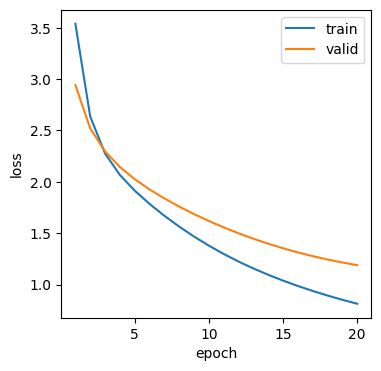

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
epochs = range(1, len(history["train"]) + 1)
ax.plot(epochs, history["train"], label="train")
ax.plot(epochs, history["valid"], label="valid")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
plt.show()

# Qualitative checks

In [19]:
# Load track lookup, keep only columns we need, inner-join with vocab
lookup = pd.read_parquet(
    "../data/playlist/track_lookup.parquet",
    columns=["track_rowid", "track_name", "artist_name", "track_popularity"],
)
lookup = lookup.merge(vocab, on="track_rowid", how="inner")
print(f"{len(lookup):,} tracks in lookup (should match vocab size {len(vocab):,})")
lookup.head()

642,015 tracks in lookup (should match vocab size 642,015)


,track_rowid,track_name,artist_name,track_popularity,track_id
0,1,The Giver,Chappell Roan,89,0
1,4,Crash,NOTD,56,1
2,5,I Just Missed A Call,NOTD,51,29
3,7,WIFI,NOTD,55,38895
4,8,SMOKE THE PAIN AWAY,Calvin Harris,75,2


In [20]:
# L2-normalise embeddings once — cosine sim becomes a simple matmul
emb = model.track_embeddings.to(device)
emb_norm = emb / emb.norm(dim=1, keepdim=True)


def find_neighbours(query: str, k: int = 10) -> pd.DataFrame:
    """Find top-k nearest neighbours by cosine similarity.

    `query` is matched case-insensitively against track_name. If multiple tracks
    match, the most popular one is used.
    """
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if matches.empty:
        print(f"No tracks matching '{query}'")
        return pd.DataFrame()

    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    tid = row["track_id"]
    print(f"Query: {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")

    sims = (emb_norm[tid] @ emb_norm.T).cpu().numpy()
    top_idx = np.argsort(sims)[::-1][1 : k + 1]  # skip self

    result = lookup[lookup["track_id"].isin(top_idx)].copy()
    result["similarity"] = sims[result["track_id"].values]
    result = result.sort_values("similarity", ascending=False)
    return result[["track_name", "artist_name", "track_popularity", "similarity"]]

In [45]:
queries = [
    "Holland, 1945",
    "Interzone",
    "About A Girl",
    "Battery",
    "Windowlicker",
    "N.Y. State of Mind",
    "Mathematics",
    "Nuthin' But A 'G' Thang",
    "Figaro",
    "Bela Lugosi's Dead",
    "Just Like Heaven",
    "Once in a Lifetime",
    "Be Quiet and Drive",
]

for q in queries:
    display(find_neighbours(q))
    print()

Query: Holland, 1945 — Neutral Milk Hotel  (pop 59)


,track_name,artist_name,track_popularity,similarity
35144,Soothe - Demo/Remastered,The Smashing Pumpkins,39,0.969349
517351,Sister I'm a Poet,Morrissey,21,0.968542
20897,Son Of Sam,Elliott Smith,54,0.968492
19143,Wave Of Mutilation,Pixies,58,0.968345
385390,Dollars and Cents,Radiohead,48,0.966843
238710,Culture,Car Seat Headrest,36,0.966006
43475,"Try, Try, Try",The Smashing Pumpkins,47,0.965769
333636,Eyes,Wine Lips,53,0.965466
333751,Birthday,The Sugarcubes,48,0.965130
333256,Spit on a Stranger,Pavement,53,0.965000



Query: Interzone - 2007 Remaster — Joy Division  (pop 47)


,track_name,artist_name,track_popularity,similarity
459462,Twenty Four Hours - 2007 Remaster,Joy Division,0,0.988572
350273,Babylon,BOAN,29,0.986266
413330,At Night,The Cure,29,0.986022
373642,Atmosphere - 2020 Digital Remaster,Joy Division,54,0.985592
357451,The Condos,Iron Curtain,22,0.985451
459463,Decades - 2007 Remaster,Joy Division,0,0.984022
394319,A God in an Alcove,Bauhaus,40,0.983654
558831,Moonchild,Fields Of The Nephilim,0,0.983234
355001,"Beauty Of Poisin - 12"" version",Specimen,31,0.983144
387035,Day of the Lords - 2007 Remaster,Joy Division,0,0.982984



Query: About A Girl — Nirvana  (pop 78)


...

,track_name,artist_name,track_popularity,similarity
287796,Love Will Tear Us Apart - 2020 Remaster,Joy Division,70,0.912080
394111,Sick & Tired,The Cardigans,44,0.904103
44005,Inbetween Days,The Cure,67,0.902899
363706,A Forest,The Cure,68,0.898336
366430,In Between Days - 2006 Remaster,The Cure,58,0.885622
346352,the king of everything,Dummy Getaway,11,0.880605
19068,Ceremony,New Order,56,0.880039
76316,Lovesong - Remastered,The Cure,70,0.878406
19073,True Faith,New Order,60,0.878345
430457,Shake the Disease,Depeche Mode,61,0.876573



Query: Once in a Lifetime - 2005 Remaster — Talking Heads  (pop 68)


,track_name,artist_name,track_popularity,similarity
420097,Heartbreak Beat,The Psychedelic Furs,32,0.927753
4405,Sanctify Yourself,Simple Minds,48,0.927305
266666,Are 'Friends' Electric? - 1998 Remaster,Tubeway Army,56,0.926464
505086,Baggy Trousers - 2010 Remaster,Madness,54,0.926307
353309,In Between Days,The Cure,37,0.924078
63170,Uncertain Smile,The The,51,0.923650
374647,"I Melt with You (7"" Mix)",Modern English,0,0.923398
462399,It Must Be Love,Madness,55,0.923306
420029,Heaven,Talking Heads,40,0.923139
24038,Hanging On The Telephone,Blondie,51,0.922322



Query: Be Quiet and Drive (Far Away) — Deftones  (pop 80)


,track_name,artist_name,track_popularity,similarity
18445,Mascara,Deftones,76,0.930006
35177,Rosemary,Deftones,76,0.915062
275922,Cherry Waves,Deftones,78,0.908544
364823,Sextape,Deftones,80,0.904807
275920,Hole in the Earth,Deftones,68,0.897489
275921,Beware,Deftones,70,0.888462
23473,Digital Bath,Deftones,73,0.882594
365328,Please Please Please Let Me Get What I Want - ...,Deftones,68,0.879591
40861,Needles and Pins,Deftones,64,0.878195
24133,Aneurysm,Nirvana,67,0.877325


## Curated genre UMAP

In [22]:
# Parse genre_artists.txt → {genre: [artist_name]}
genre_artists = {}
current_genre = None
with open("genre_artists.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            current_genre = line[1:].strip()
            genre_artists[current_genre] = []
        else:
            genre_artists[current_genre].append(line)

for g, artists in genre_artists.items():
    print(f"{g}: {len(artists)} artists")

new-wave: 14 artists
post-punk: 14 artists
70s-punk: 13 artists
grunge: 13 artists
thrash-metal: 13 artists
black-metal: 13 artists
dark-wave: 13 artists
90s-west-coast-hip-hop: 13 artists
90s-east-coast-hip-hop: 13 artists
conscious-hip-hop: 13 artists
IDM: 13 artists


In [23]:
# Join curated artists with lookup to get their tracks + track_ids
rows = []
for genre, artists in genre_artists.items():
    for artist in artists:
        mask = lookup["artist_name"].str.lower() == artist.lower()
        matched = lookup[mask]
        for _, row in matched.iterrows():
            rows.append({
                "genre": genre,
                "artist_name": row["artist_name"],
                "track_name": row["track_name"],
                "track_id": row["track_id"],
            })

genre_df = pd.DataFrame(rows)
print(f"{len(genre_df):,} tracks matched across {genre_df['genre'].nunique()} genres")
print(f"{genre_df['artist_name'].str.lower().nunique()} unique artists matched")
print()
print(genre_df["genre"].value_counts().to_string())

5,690 tracks matched across 11 genres
137 unique artists matched

genre
90s-east-coast-hip-hop    991
90s-west-coast-hip-hop    931
new-wave                  808
thrash-metal              660
grunge                    604
conscious-hip-hop         517
post-punk                 417
70s-punk                  271
IDM                       252
dark-wave                 170
black-metal                69


In [24]:
import umap

# Extract embeddings for the curated tracks
track_ids = genre_df["track_id"].values
genre_emb = emb_norm[track_ids].cpu().numpy()

reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42)
coords = reducer.fit_transform(genre_emb)
genre_df["umap_x"] = coords[:, 0]
genre_df["umap_y"] = coords[:, 1]
print(f"UMAP done — {len(coords)} points")

/home/peppe/Dropbox/Progetti/ml/spotify-rec/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done — 5690 points


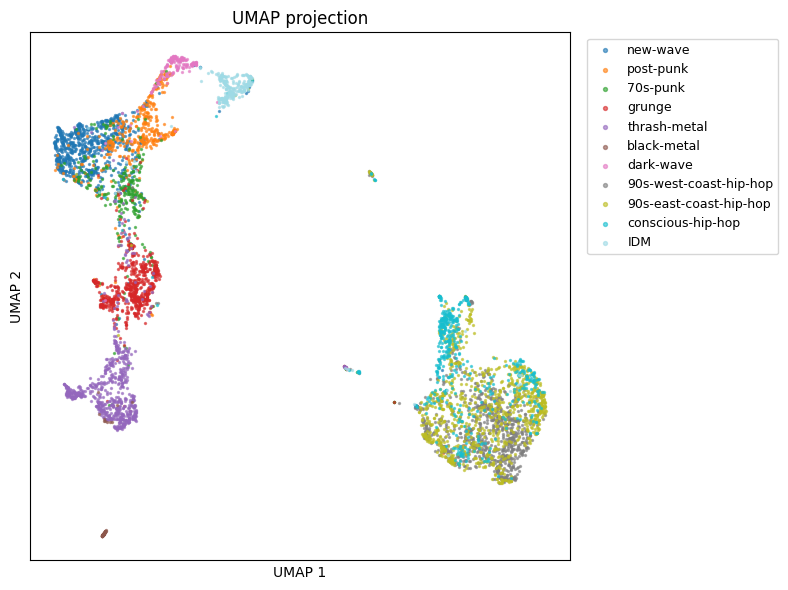

In [35]:
import matplotlib

fig, ax = plt.subplots(figsize=(8, 6))

genres = genre_df["genre"].unique()
cmap = plt.colormaps["tab20"].resampled(len(genres))

for i, genre in enumerate(genres):
    subset = genre_df[genre_df["genre"] == genre]
    ax.scatter(
        subset["umap_x"], subset["umap_y"],
        c=[cmap(i)], label=genre, s=2, alpha=0.6,
    )

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, markerscale=2)
ax.set_title("UMAP projection")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()